**Отчёт по расчётно-графической работе.**

**Мурманский арктический университет**  
*Институт интеллектуальных систем и цифровых технологий*  
*Кафедра цифровых технологий, математики и экономики*  

**Дисциплина:** Машинное обучение и нейронные сети  
**Преподаватель** Золотов О.В.  
**Студент:** Михайлов Е.С., группа ИВТб22о-2

**Тема:** исследовательский анализ данных микропроцессора детектора SSIES спутников DMSP

**Цель работы:** Разработать программный модуль для чтения, разбора и преобразования бинарных данных микропроцессора SSIES (Special Sensor for Ion and Electron Scintillation) из формата MP (Microprocessor), построить две модели с использованием стандартных методов машинного обучения или ИНС.

**Исходные данные:** Заархивированный файл .gz с бинарными данными SSIES MP формата

In [ ]:
# Импорт библиотек для работы с данными и математических операций
import numpy as np  # Для работы с массивами и математических операций
import pandas as pd  # Для работы с таблицами данных
import matplotlib.pyplot as plt  # Для построения графиков и визуализации
from sklearn.model_selection import train_test_split  # Для разделения данных на обучение и тест
from sklearn.preprocessing import StandardScaler  # Для масштабирования признаков
from sklearn.linear_model import Ridge  # Для модели Ridge регрессии с регуляризацией
from sklearn.ensemble import RandomForestRegressor  # Для модели случайного леса
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Метрики качества моделей
from sklearn.model_selection import train_test_split # Для разделения тренировочных и тестовых данных
import gzip  # Для работы с gzip архивами (данные сжаты)
import struct  # Для работы с бинарными данными и их разбора
from datetime import datetime, timedelta  # Для работы с датами и временем
import warnings  # Для управления предупреждениями
import time  # Для измерения времени выполнения операций
warnings.filterwarnings('ignore')  # Игнорировать предупреждения для чистоты вывода

**Постановка задачи и выбор целевых переменных**

Для анализа данных космических миссий необходимо использовать методы машинного обучения, которые могут выявлять сложные зависимости между физическими параметрами ионосферы. В данной работе мы будем предсказывать плотность ионов кислорода (O_density_raw) и температуру ионов кислорода (O_temp_raw) на основе других измеряемых параметров. Выбор этих параметров обусловлен их физической значимостью для анализа ионосферных процессов.

In [ ]:
# Определение структуры заголовка файла данных
# Каждый элемент: (имя_поля, размер_в_байтах, тип_данных, [преобразование])
HEADER_SPEC = [
    ('spacecraft_id', 4, 'str'),  # Идентификатор космического аппарата
    ('data_file_id', 6, 'str'),   # Идентификатор файла данных
    ('year_raw', 2, 'uint16', lambda x: x + 1950),  # Год (преобразование из смещения)
    ('day_of_year', 2, 'uint16'),  # День года
    ('hour', 1, 'uint8'),          # Час
    ('minute', 1, 'uint8'),        # Минута
    ('geo_lat_raw', 2, 'int16', lambda x: x/10.0 - 90.0),  # Географическая широта
    ('geo_lon_raw', 2, 'uint16', lambda x: x/10.0),  # Географическая долгота
    ('mag_lat_raw', 2, 'int16', lambda x: x/10.0 - 90.0),  # Магнитная широта
    ('mlt_raw', 2, 'uint16', lambda x: x/10.0),  # Местное магнитное время
    ('mag_lon_raw', 2, 'uint16', lambda x: x/10.0),  # Магнитная долгота
    ('subsol_lat_raw', 2, 'int16', lambda x: x/10.0 - 90.0),  # Широта подсолнечной точки
    ('subsol_lon_raw', 2, 'uint16', lambda x: x/10.0),  # Долгота подсолнечной точки
    ('footprint_lat_raw', 2, 'int16', lambda x: x/10.0 - 90.0),  # Широта проекции
    ('footprint_lon_raw', 2, 'uint16', lambda x: x/10.0),  # Долгота проекции
    ('cgm_lat_raw', 2, 'int16', lambda x: x/10.0 - 90.0),  # Широта в координатах CGM
    ('cgm_lon_raw', 2, 'uint16', lambda x: x/10.0),  # Долгота в координатах CGM
    ('invariant_lat_raw', 2, 'uint16', lambda x: x/10.0),  # Инвариантная широта
    ('altitude_start', 2, 'uint16'),  # Начальная высота
    ('altitude_end', 2, 'uint16'),    # Конечная высота
    ('B_north_raw', 4, 'int32', lambda x: x/10.0 - 70000.0),  # Компонента магнитного поля (север)
    ('B_east_raw', 4, 'int32', lambda x: x/10.0 - 70000.0),   # Компонента магнитного поля (восток)
    ('B_down_raw', 4, 'int32', lambda x: x/10.0 - 70000.0),   # Компонента магнитного поля (вниз)
    ('pos_x_raw', 3, 'int24', lambda x: x/100000.0 - 1.0),    # Позиция X
    ('pos_y_raw', 3, 'int24', lambda x: x/100000.0 - 1.0),    # Позиция Y
    ('pos_z_raw', 3, 'int24', lambda x: x/100000.0 - 1.0),    # Позиция Z
    ('potential_flag', 1, 'uint8'),   # Флаг потенциала
    ('sc_potential_raw', 1, 'int8', lambda x: x - 10),  # Потенциал космического аппарата
    ('ion_potential_raw', 1, 'int8', lambda x: x - 3),  # Ионный потенциал
    ('drift_meter_func', 1, 'uint8'),  # Функция дрифт-метра
    ('scint_filter_cmd', 1, 'uint8'),  # Команда фильтра сцинтилляций
    ('n_sets', 1, 'uint8')  # Количество наборов измерений в записи
]

# Определение структуры набора измерений (сета)
SET_SPEC = [
    ('second', 1, 'uint8'),  # Секунда
    ('ram_drift_raw', 2, 'int16', lambda x: x * 10.0 - 3000.0),  # Дрифт в направлении движения
    ('O_temp_raw', 2, 'uint16', lambda x: x * 10.0),  # Температура ионов кислорода
    ('H_temp_raw', 2, 'uint16', lambda x: x * 10.0),  # Температура ионов водорода
    ('O_density_raw', 2, 'uint16', lambda x: 10 ** (x / 100.0)),  # Плотность ионов кислорода (логарифмическая шкала)
    ('H_density_raw', 2, 'uint16', lambda x: 10 ** (x / 100.0)),  # Плотность ионов водорода (логарифмическая шкала)
    ('plasma_potential_raw', 2, 'int16', lambda x: x / 100.0 - 6.0),  # Плазменный потенциал
    ('e_temp_1_raw', 2, 'uint16', lambda x: x * 10.0),  # Температура электронов 1
    ('e_density_1_raw', 2, 'uint16', lambda x: 10 ** (x / 100.0)),  # Плотность электронов 1
    ('sc_potential_1_raw', 2, 'int16', lambda x: 6.0 - x / 10.0),  # Потенциал КА 1
    ('e_temp_2_raw', 2, 'uint16', lambda x: x * 10.0),  # Температура электронов 2
    ('e_density_2_raw', 2, 'uint16', lambda x: 10 ** (x / 100.0)),  # Плотность электронов 2
    ('sc_potential_2_raw', 2, 'int16', lambda x: 6.0 - x / 10.0),  # Потенциал КА 2
    ('zero_fill', 3, 'bytes')  # Заполнитель (нулевые байты)
]

# Вычисление размеров структур для корректного чтения данных
HEADER_SIZE = sum(item[1] for item in HEADER_SPEC)  # Размер заголовка в байтах
SET_SIZE = sum(item[1] for item in SET_SPEC)  # Размер одного набора измерений в байтах

**Структура данных SSIES MP формата**

Формат данных SSIES MP содержит заголовок и наборы измерений (сеты). Каждый параметр имеет специфическое преобразование из сырых значений в физические величины, что необходимо учитывать при обработке данных. В частности, плотность ионов кислорода вычисляется по экспоненциальной формуле, что отражает логарифмический характер измерений этого параметра.

**Описание класса для чтения данных**

Класс SSIESMPReader реализует чтение бинарных данных, их преобразование в физические величины и сохранение в виде DataFrame. Это обеспечивает структурированное представление данных для последующего анализа. Важной особенностью является обработка различных типов данных (uint8, int16, int24, int32) и преобразование их в физические величины с использованием лямбда-функций, определенных в спецификации формата данных.

In [ ]:
class SSIESMPReader:
    """
    Класс для чтения и преобразования бинарных данных SSIES MP формата.
    Осуществляет разбор сырых бинарных данных, преобразование в физические величины
    и сохранение в структурированном виде.
    """

    def __init__(self, filepath):
        """Инициализация читателя с указанием пути к файлу данных."""
        self.filepath = filepath  # Путь к файлу с данными
        self.data = None  # Сырые бинарные данные
        self.phys_records = []  # Список физических записей
        self.timestamps = []  # Список временных меток
        self.padding_offset = 0  # Смещение для выравнивания данных

    def read_binary_value(self, data, pos, size, dtype, conversion=None):
        """
        Чтение бинарного значения из данных.

        Args:
            data: Бинарные данные
            pos: Позиция для чтения
            size: Размер значения в байтах
            dtype: Тип данных
            conversion: Функция преобразования сырого значения

        Returns:
            Прочитанное и преобразованное значение
        """
        # Проверка наличия достаточного количества данных
        if pos + size > len(data):
            raise IndexError(f"Недостаточно данных для чтения значения")

        # Извлечение фрагмента данных
        chunk = data[pos:pos+size]

        # Обработка различных типов данных
        if dtype == 'str':
            # Декодирование строки из ASCII
            return chunk.decode('ascii', errors='ignore').strip()
        elif dtype == 'bytes':
            # Возврат сырых байтов
            return chunk
        elif dtype == 'uint8':
            # Беззнаковый байт
            value = chunk[0]
        elif dtype == 'int8':
            # Знаковый байт
            value = struct.unpack('>b', chunk)[0]
        elif dtype == 'uint16':
            # Беззнаковое 16-битное число
            value = struct.unpack('>H', chunk)[0]
        elif dtype == 'int16':
            # Знаковое 16-битное число
            value = struct.unpack('>h', chunk)[0]
        elif dtype == 'int32':
            # Знаковое 32-битное число
            value = struct.unpack('>i', chunk)[0]
        elif dtype == 'int24':
            # 24-битное число (особый случай)
            if len(chunk) == 3:
                # Дополнение до 4 байт для корректного распаковки
                chunk = b'\x00' + chunk if chunk[0] < 0x80 else b'\xFF' + chunk
            value = struct.unpack('>i', chunk)[0]
            # Коррекция знака для 24-битного числа
            if value & 0x800000:
                value |= 0xFF000000
            else:
                value &= 0x00FFFFFF
        else:
            raise ValueError(f"Неизвестный тип данных: {dtype}")

        # Применение функции преобразования если она указана
        if conversion:
            return conversion(value)
        return value

    def detect_padding(self, data):
        """
        Определение смещения для выравнивания данных.
        Ищет корректные значения года для определения правильного смещения.
        """
        for offset in [0, 1, 2]:
            if 10 + offset + 2 <= len(data):
                year_raw = struct.unpack('>H', data[10+offset:10+offset+2])[0]
                year = year_raw + 1950
                if 1980 <= year <= 2050:
                    return offset
        return 0

    def parse_file(self):
        """Основной метод разбора файла данных."""
        # Открытие и чтение сжатого файла
        with gzip.open(self.filepath, 'rb') as f:
            self.data = f.read()

        print(f"Загружено байт данных: {len(self.data)}")

        # Определение смещения для выравнивания
        self.padding_offset = self.detect_padding(self.data[:50])

        pos = 0  # Текущая позиция в данных
        minute_count = 0  # Счетчик минутных записей
        total_records = 0  # Общий счетчик записей

        # Основной цикл чтения данных
        while pos < len(self.data) - HEADER_SIZE - self.padding_offset:
            try:
                header_start = pos  # Запоминаем начало заголовка
                phys_header = {}  # Словарь для данных заголовка

                # Чтение идентификаторов космического аппарата и файла
                spacecraft_id = self.read_binary_value(self.data, pos, 4, 'str')
                pos += 4
                data_file_id = self.read_binary_value(self.data, pos, 6, 'str')
                pos += 6

                # Проверка корректности идентификаторов
                if not (spacecraft_id.startswith('F') and 'MICRO' in data_file_id):
                    pos = header_start + 1
                    continue

                phys_header['spacecraft_id'] = spacecraft_id
                phys_header['data_file_id'] = data_file_id

                # Учет смещения для выравнивания
                if self.padding_offset > 0:
                    pos += self.padding_offset

                # Чтение полей заголовка (кроме уже прочитанных идентификаторов)
                header_fields = HEADER_SPEC[2:]

                for name, size, dtype, *conversion in header_fields:
                    conv_func = conversion[0] if conversion else None
                    raw_value = self.read_binary_value(self.data, pos, size, dtype, None)
                    pos += size

                    # Применение преобразования если указано
                    if conv_func:
                        try:
                            phys_header[name] = conv_func(raw_value)
                        except Exception:
                            phys_header[name] = np.nan
                    else:
                        phys_header[name] = raw_value

                # Проверка корректности года
                year = phys_header.get('year_raw')
                if not (1987 <= year <= 2049):
                    pos = header_start + 1
                    continue

                # Определение количества наборов измерений в записи
                n_sets = phys_header.get('n_sets', 1)
                if n_sets < 1 or n_sets > 15:
                    n_sets = 1

                # Чтение наборов измерений
                for set_idx in range(n_sets):
                    phys_set = {}  # Словарь для данных набора измерений

                    for name, size, dtype, *conversion in SET_SPEC:
                        conv_func = conversion[0] if conversion else None
                        raw_value = self.read_binary_value(self.data, pos, size, dtype, None)
                        pos += size

                        # Применение преобразования
                        if conv_func:
                            try:
                                phys_set[name] = conv_func(raw_value)
                            except Exception:
                                phys_set[name] = np.nan
                        else:
                            phys_set[name] = raw_value

                    # Объединение заголовка и набора измерений
                    full_phys_record = phys_header.copy()
                    full_phys_record.update(phys_set)

                    # Создание временной метки
                    try:
                        year = phys_header['year_raw']
                        doy = phys_header['day_of_year']
                        hour = phys_header.get('hour', 0)
                        minute_val = phys_header.get('minute', 0)
                        second = phys_set.get('second', 0)

                        dt = datetime(year, 1, 1) + timedelta(
                            days=doy-1,
                            hours=hour,
                            minutes=minute_val,
                            seconds=second
                        )

                        self.timestamps.append(dt)
                        self.phys_records.append(full_phys_record)
                        total_records += 1

                    except Exception:
                        continue

                minute_count += 1

                # Пропуск неиспользуемых наборов измерений (если их меньше 15)
                remaining_sets = 15 - n_sets
                pos += remaining_sets * SET_SIZE

            except Exception:
                # В случае ошибки переходим к следующей возможной позиции
                pos = header_start + 1 if 'header_start' in locals() else pos + 1
                continue

        print(f"Парсинг завершен. Минутных записей: {minute_count}, Всего записей: {total_records}")
        return self

    def get_phys_dataframe(self):
        """Преобразование прочитанных данных в DataFrame pandas."""
        if len(self.phys_records) == 0:
            return None

        # Создание DataFrame из записей
        df = pd.DataFrame(self.phys_records)
        df['time'] = self.timestamps  # Добавление колонки времени
        df.set_index('time', inplace=True)  # Установка времени как индекса
        return df

**Предварительная обработка данных**

Предварительная обработка данных включает выбор релевантных признаков, удаление пропущенных значений и анализ базовой статистики. Это важный этап для подготовки данных к машинному обучению. В нашем случае мы фокусируемся на двух целевых переменных: плотности ионов кислорода (O_density_raw) и температуре ионов кислорода (O_temp_raw), которые являются ключевыми параметрами для анализа ионосферных процессов.

In [ ]:
# Определение пути к файлу с данными
file_path = "f08mp87jun25.dat.gz"

print("=" * 70)
print("ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ SSIES MP")
print(f"Файл: {file_path}")
print("=" * 70)

# Создание экземпляра читателя и парсинг файла
reader = SSIESMPReader(file_path)
reader.parse_file()
df = reader.get_phys_dataframe()

# Проверка успешности загрузки данных
if df is not None:
    print(f"\nРазмер загруженного DataFrame: {df.shape}")
    print(f"Колонки в данных: {list(df.columns)[:15]}...")

    # Выбор ключевых колонок для анализа на основе физической значимости
    key_columns = [
        'O_density_raw', 'O_temp_raw',  # Целевые переменные
        'ram_drift_raw', 'H_temp_raw', 'H_density_raw',  # Параметры ионов водорода
        'geo_lat_raw', 'geo_lon_raw', 'mag_lat_raw',  # Географические параметры
        'altitude_start', 'mlt_raw'  # Высота и магнитное местное время
    ]

    # Фильтрация только существующих колонок
    existing_columns = [col for col in key_columns if col in df.columns]
    df = df[existing_columns]

    # Удаление строк с пропущенными значениями
    df_clean = df.dropna()
    print(f"\nДанные после удаления пропущенных значений: {df_clean.shape}")
    print(f"Удалено строк с NaN: {len(df) - len(df_clean)}")

    # Вывод базовой статистики по целевым переменным
    print("\nБазовая статистика по ключевым параметрам:")
    print(df_clean[['O_density_raw', 'O_temp_raw']].describe())

    # Сохранение очищенных данных для использования в следующих блоках
    df_clean_global = df_clean

else:
    print("Ошибка: не удалось загрузить данные из файла")
    df_clean_global = None

ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ SSIES MP
Файл: f08mp87jun25.dat.gz
Загружено байт данных: 137760
Парсинг завершен. Минутных записей: 264, Всего записей: 3639

Размер загруженного DataFrame: (3639, 46)
Колонки в данных: ['spacecraft_id', 'data_file_id', 'year_raw', 'day_of_year', 'hour', 'minute', 'geo_lat_raw', 'geo_lon_raw', 'mag_lat_raw', 'mlt_raw', 'mag_lon_raw', 'subsol_lat_raw', 'subsol_lon_raw', 'footprint_lat_raw', 'footprint_lon_raw']...

Данные после удаления пропущенных значений: (2215, 10)
Удалено строк с NaN: 1424

Базовая статистика по ключевым параметрам:
       O_density_raw     O_temp_raw
count    2215.000000    2215.000000
mean    20481.804905   61662.306998
std     22531.527234  188621.758390
min        10.000000     500.000000
25%     13803.842646    1480.000000
50%     20417.379447    1800.000000
75%     26302.679919    2160.000000
max    977237.220956  655350.000000


**Анализ временных рядов и корреляций**

Исследовательский анализ данных позволяет выявить распределения параметров, корреляции между ними и временные закономерности. Это помогает в выборе признаков для моделей и понимании физических процессов. Графики временных рядов показывают динамику изменения параметров во времени, а scatter plot демонстрирует взаимосвязь между плотностью и температурой ионов кислорода.

ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)
Данные до фильтрации выбросов: (2215, 10)
Данные после фильтрации выбросов: (1415, 10)
Данные для анализа (первые 1000): (1000, 10)
Применено скользящее среднее с окном 20 для сглаживания данных


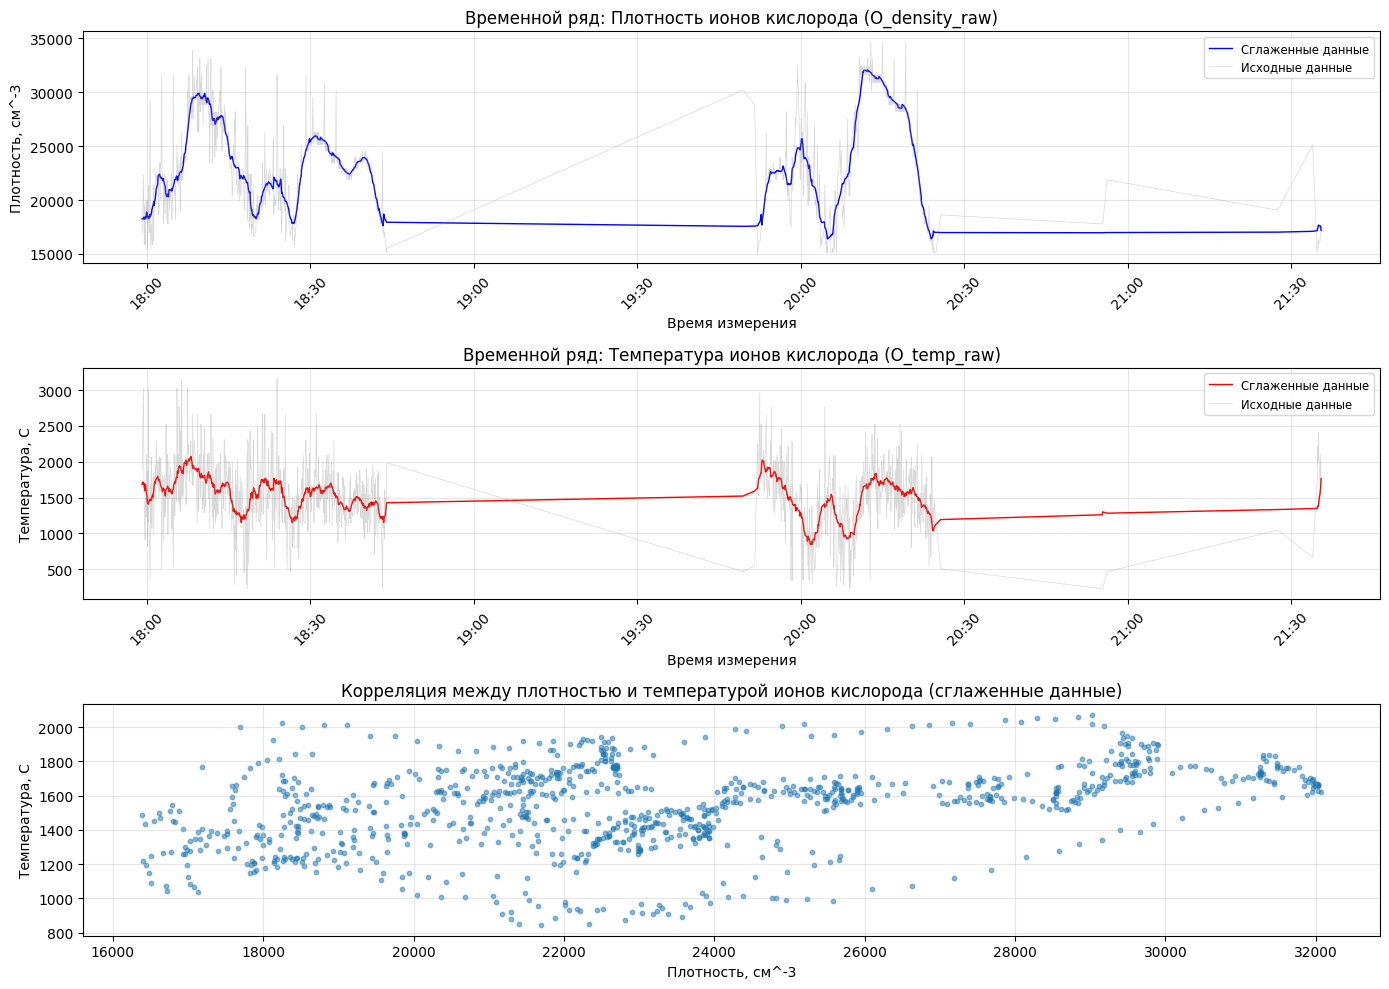


Корреляция между O_density_raw и O_temp_raw (сглаженные данные):
Коэффициент корреляции: 0.3893
Умеренная корреляция между параметрами


In [ ]:
print("=" * 70)
print("ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)")
print("=" * 70)

# Проверка наличия данных для анализа
if df_clean_global is not None:
    # Фильтрация выбросов для получения более чистых данных
    mask_density = (df_clean_global['O_density_raw'] >= 15000) & (df_clean_global['O_density_raw'] <= 35000)
    mask_temp = (df_clean_global['O_temp_raw'] >= 500) & (df_clean_global['O_temp_raw'] <= 3500)
    mask_combined = mask_density & mask_temp

    df_filtered = df_clean_global[mask_combined].copy()

    # Используем первые 1000 измерений после фильтрации
    n_points = 1000
    if len(df_filtered) >= n_points:
        df_1000 = df_filtered.iloc[:n_points].copy()
    else:
        df_1000 = df_filtered.copy()
        print(f"Внимание: после фильтрации доступно только {len(df_filtered)} точек")

    # Применяем скользящее среднее для сглаживания данных
    window_size = 20  # Размер окна для скользящего среднего
    df_1000_smooth = df_1000.copy()

    # Сглаживаем только числовые колонки
    numeric_cols = df_1000.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df_1000_smooth[col] = df_1000[col].rolling(window=window_size, center=True, min_periods=1).mean()

    print(f"Данные до фильтрации выбросов: {df_clean_global.shape}")
    print(f"Данные после фильтрации выбросов: {df_filtered.shape}")
    print(f"Данные для анализа (первые {len(df_1000)}): {df_1000.shape}")
    print(f"Применено скользящее среднее с окном {window_size} для сглаживания данных")

    # Временные ряды для O_density_raw и O_temp_raw
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Настройка формата даты для отображения только времени (час:минута)
    import matplotlib.dates as mdates

    # График 1: Плотность ионов кислорода во времени (сглаженная)
    axes[0].plot(df_1000_smooth.index, df_1000_smooth['O_density_raw'].values, 'b-', linewidth=1, label='Сглаженные данные')
    axes[0].plot(df_1000.index, df_1000['O_density_raw'].values, 'gray', alpha=0.3, linewidth=0.5, label='Исходные данные')
    axes[0].set_title('Временной ряд: Плотность ионов кислорода (O_density_raw)')
    axes[0].set_xlabel('Время измерения')
    axes[0].set_ylabel('Плотность, см^-3')
    axes[0].grid(True, alpha=0.3)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(loc='best', fontsize='small')

    # График 2: Температура ионов кислорода во времени (сглаженная)
    axes[1].plot(df_1000_smooth.index, (df_1000_smooth['O_temp_raw'].values - 273.15), 'r-', linewidth=1, label='Сглаженные данные')
    axes[1].plot(df_1000.index, (df_1000['O_temp_raw'].values - 273.15), 'gray', alpha=0.3, linewidth=0.5, label='Исходные данные')
    axes[1].set_title('Временной ряд: Температура ионов кислорода (O_temp_raw)')
    axes[1].set_xlabel('Время измерения')
    axes[1].set_ylabel('Температура, C')
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(loc='best', fontsize='small')

    # График 3: Корреляция между плотностью и температурой (сглаженные данные)
    axes[2].scatter(df_1000_smooth['O_density_raw'].values,
                   (df_1000_smooth['O_temp_raw'].values - 273.15),
                   alpha=0.5, s=10)
    axes[2].set_title('Корреляция между плотностью и температурой ионов кислорода (сглаженные данные)')
    axes[2].set_xlabel('Плотность, см^-3')
    axes[2].set_ylabel('Температура, C')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Анализ корреляции между целевыми переменными (на сглаженных данных)
    print("\nКорреляция между O_density_raw и O_temp_raw (сглаженные данные):")
    correlation = df_1000_smooth['O_density_raw'].corr(df_1000_smooth['O_temp_raw'])
    print(f"Коэффициент корреляции: {correlation:.4f}")

    if abs(correlation) > 0.7:
        print("Сильная корреляция между параметрами")
    elif abs(correlation) > 0.3:
        print("Умеренная корреляция между параметрами")
    else:
        print("Слабая корреляция между параметрами")

    # Сохранение сглаженных данных для использования в следующих блоках
    df_1000_smooth_global = df_1000_smooth
else:
    print("Ошибка: нет данных для исследовательского анализа")
    df_1000_smooth_global = None

**Разделение данных и масштабирование**

Подготовка данных включает разделение на обучающую и тестовую выборки, а также масштабирование признаков. Это необходимо для корректной работы алгоритмов машинного обучения и оценки их обобщающей способности. Мы создаем отдельные наборы данных для предсказания плотности и температуры ионов кислорода, используя одни и те же признаки (за исключением самих целевых переменных).

In [ ]:
print("=" * 70)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ МАШИННОГО ОБУЧЕНИЯ")
print("=" * 70)

# Проверка наличия данных для подготовки
if df_1000_smooth_global is not None:
    # Используем сглаженные данные для обучения моделей
    df_1000_smooth = df_1000_smooth_global.copy()

    # Определение независимых признаков на основе физической значимости
    feature_columns = [
        'ram_drift_raw', 'H_temp_raw', 'H_density_raw',
        'geo_lat_raw', 'geo_lon_raw', 'mag_lat_raw',
        'altitude_start', 'mlt_raw'
    ]

    # Фильтрация только существующих признаков
    feature_columns = [col for col in feature_columns if col in df_1000_smooth.columns]

    print(f"Используемые признаки ({len(feature_columns)}):")
    for i, feat in enumerate(feature_columns, 1):
        print(f"  {i:2d}. {feat}")

    # Подготовка данных для плотности ионов кислорода
    target_density = 'O_density_raw'

    X_density = df_1000_smooth[feature_columns].values
    y_density = df_1000_smooth[target_density].values
    time_indices_density = df_1000_smooth.index

    # Подготовка данных для температуры ионов кислорода
    target_temp = 'O_temp_raw'

    X_temp = df_1000_smooth[feature_columns].values
    y_temp = df_1000_smooth[target_temp].values
    time_indices_temp = df_1000_smooth.index

    print(f"\nКонфигурация данных:")
    print(f"Всего точек: {df_1000_smooth.shape[0]}")
    print(f"Признаков: {len(feature_columns)}")
    print(f"Целевые переменные: {target_density}, {target_temp}")
    print(f"Размерность X_density: {X_density.shape}")
    print(f"Размерность X_temp: {X_temp.shape}")

    # Последовательное разделение данных: 80% для обучения, 20% для тестирования
    len_ = len(X_density)
    test_size = int(0.2 * len_)  #20% для теста
    train_size = len_ - test_size

    print(f"\nРазделение данных:")
    print(f"Всего точек: {len_}")
    print(f"Обучающая выборка: {train_size} точек (80.0% от данных)")
    print(f"Тестовая выборка: {test_size} точек (20.0% от данных)")

    # Определяем индексы для обучения и теста
    train_indices = np.arange(train_size)
    test_indices = np.arange(train_size, len_)

    # Разделение для плотности
    X_train_density = X_density[train_indices]
    X_test_density = X_density[test_indices]
    y_train_density = y_density[train_indices]
    y_test_density = y_density[test_indices]
    time_train_density = time_indices_density[train_indices]
    time_test_density = time_indices_density[test_indices]

    # Разделение для температуры
    X_train_temp = X_temp[train_indices]
    X_test_temp = X_temp[test_indices]
    y_train_temp = y_temp[train_indices]
    y_test_temp = y_temp[test_indices]
    time_train_temp = time_indices_temp[train_indices]
    time_test_temp = time_indices_temp[test_indices]

    # Обновляем len_ для использования в дальнейших расчетах
    len_ = len(X_density)

    print(f"\nРазделение данных:")
    print(f"Обучающая выборка: {len(X_train_density)} точек ({len(X_train_density)/len_*100:.1f}% от данных)")
    print(f"Тестовая выборка: {len(X_test_density)} точек ({len(X_test_density)/len_*100:.1f}% от данных)")

    # Масштабирование признаков для плотности (стандартизация)
    scaler_X_density = StandardScaler()
    X_train_density_scaled = scaler_X_density.fit_transform(X_train_density)
    X_test_density_scaled = scaler_X_density.transform(X_test_density)

    scaler_y_density = StandardScaler()
    y_train_density_scaled = scaler_y_density.fit_transform(y_train_density.reshape(-1, 1)).ravel()
    y_test_density_scaled = scaler_y_density.transform(y_test_density.reshape(-1, 1)).ravel()

    # Масштабирование признаков для температуры (стандартизация)
    scaler_X_temp = StandardScaler()
    X_train_temp_scaled = scaler_X_temp.fit_transform(X_train_temp)
    X_test_temp_scaled = scaler_X_temp.transform(X_test_temp)

    scaler_y_temp = StandardScaler()
    y_train_temp_scaled = scaler_y_temp.fit_transform(y_train_temp.reshape(-1, 1)).ravel()
    y_test_temp_scaled = scaler_y_temp.transform(y_test_temp.reshape(-1, 1)).ravel()

    # Вычисление пределов для графиков на основе обучающей выборки
    ylim_density = [y_train_density.min() * 0.9, y_train_density.max() * 1.1]
    y_train_temp_celsius = y_train_temp - 273.15
    ylim_temp_celsius = [y_train_temp_celsius.min() * 0.9, y_train_temp_celsius.max() * 1.1]

    print("\nНастройка завершена:")
    print(f"Масштабирование данных выполнено")
    print(f"Пределы для графиков плотности: {ylim_density[0]:.0f} - {ylim_density[1]:.0f} см^-3")
    print(f"Пределы для графиков температуры: {ylim_temp_celsius[0]:.0f} - {ylim_temp_celsius[1]:.0f} C")

    # Сохранение подготовленных данных для использования в моделях
    data_prepared = True

else:
    print("Ошибка: нет данных для подготовки к машинному обучению")
    data_prepared = False

ПОДГОТОВКА ДАННЫХ ДЛЯ МАШИННОГО ОБУЧЕНИЯ
Используемые признаки (8):
   1. ram_drift_raw
   2. H_temp_raw
   3. H_density_raw
   4. geo_lat_raw
   5. geo_lon_raw
   6. mag_lat_raw
   7. altitude_start
   8. mlt_raw

Конфигурация данных:
Всего точек: 1000
Признаков: 8
Целевые переменные: O_density_raw, O_temp_raw
Размерность X_density: (1000, 8)
Размерность X_temp: (1000, 8)

Разделение данных:
Всего точек: 1000
Обучающая выборка: 800 точек (80.0% от данных)
Тестовая выборка: 200 точек (20.0% от данных)

Разделение данных:
Обучающая выборка: 800 точек (80.0% от данных)
Тестовая выборка: 200 точек (20.0% от данных)

Настройка завершена:
Масштабирование данных выполнено
Пределы для графиков плотности: 14750 - 32895 см^-3
Пределы для графиков температуры: 759 - 2281 C


**Обоснование выбора Ridge регрессии**

Ridge регрессия добавляет регуляризацию L2 к линейной модели, что уменьшает переобучение при наличии мультиколлинеарности. Модель обучается быстро и дает интерпретируемые результаты. Временные ряды предсказаний показывают, насколько хорошо модель воспроизводит динамику изменений плотности и температуры ионов кислорода на обучающих и тестовых данных.

МОДЕЛЬ 1: RIDGE РЕГРЕССИЯ
Обоснование выбора модели:
Ridge регрессия - линейная модель с регуляризацией L2.
Подходит для данных с возможной мультиколлинеарностью признаков.
Быстрое обучение и хорошая интерпретируемость результатов.
Регуляризация L2 помогает предотвратить переобучение модели.

Метрики качества модели Ridge регрессии:

Для плотности ионов кислорода:
  MSE на обучающей выборке: 9355710.0524
  MSE на тестовой выборке: 40654020.0789
  MAE на обучающей выборке: 2530.4108
  MAE на тестовой выборке: 6007.7566
  R^2 на обучающей выборке: 0.0674
  R^2 на тестовой выборке: -0.3296

Для температуры ионов кислорода:
  MSE на обучающей выборке: 27394.0958
  MSE на тестовой выборке: 323403.2233
  MAE на обучающей выборке: 128.8533
  MAE на тестовой выборке: 535.2333
  R^2 на обучающей выборке: 0.5697
  R^2 на тестовой выборке: -9.2600


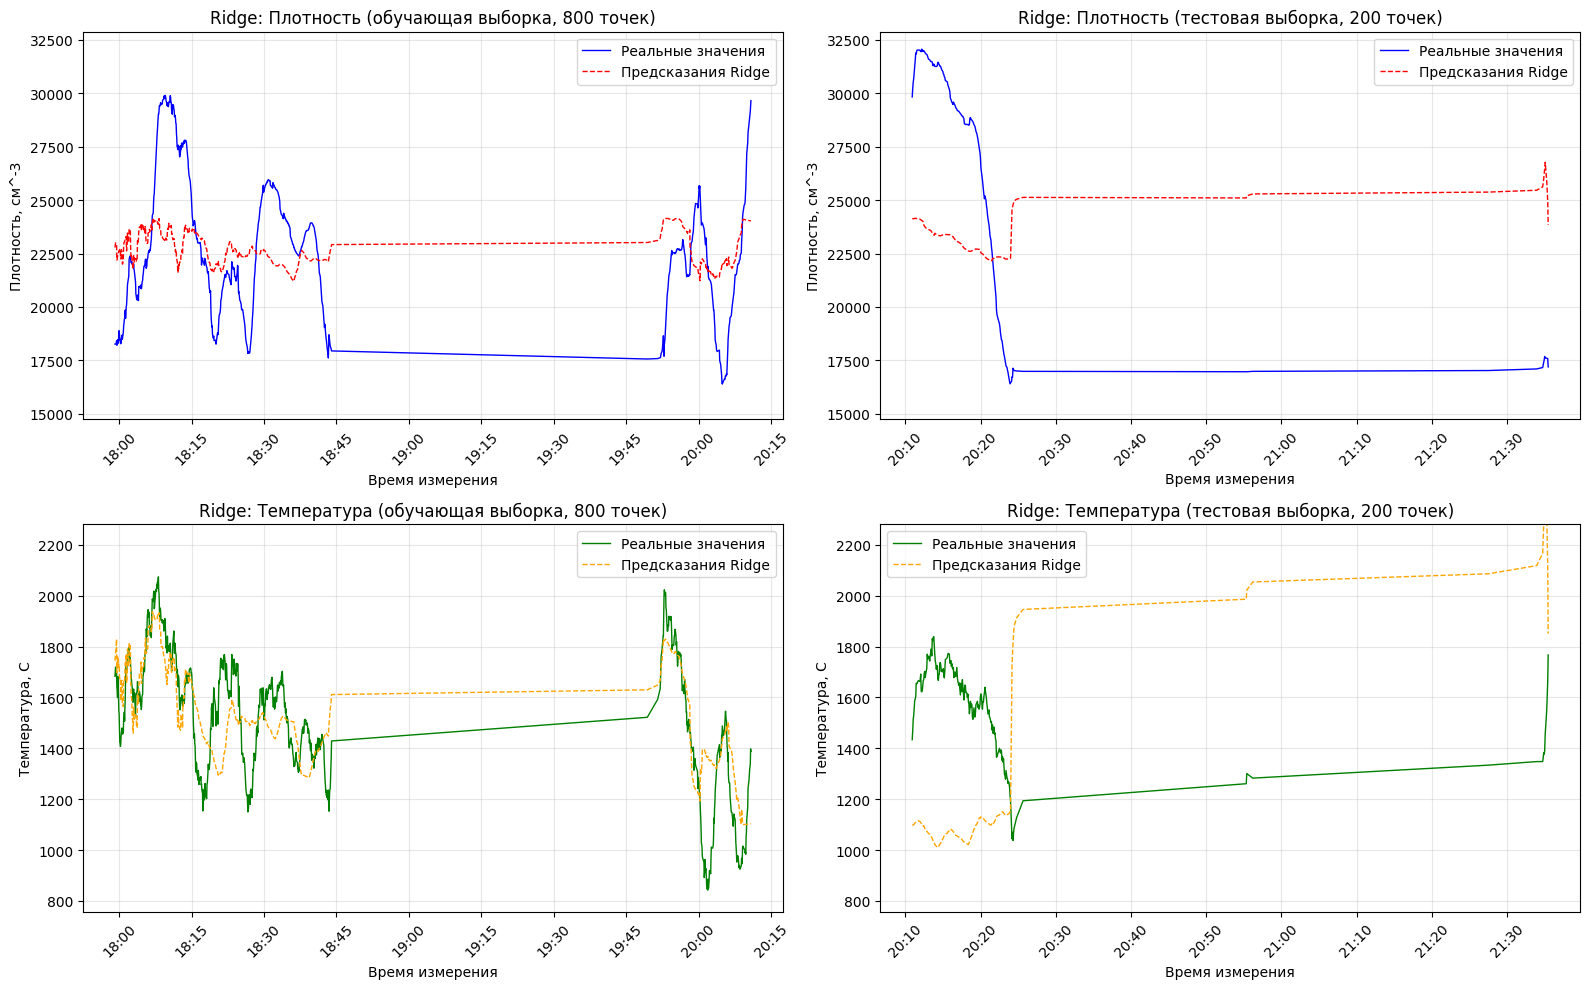


Модель Ridge регрессии успешно обучена и оценена.


In [ ]:
print("=" * 70)
print("МОДЕЛЬ 1: RIDGE РЕГРЕССИЯ")
print("=" * 70)

# Обоснование выбора модели
print("Обоснование выбора модели:")
print("Ridge регрессия - линейная модель с регуляризацией L2.")
print("Подходит для данных с возможной мультиколлинеарностью признаков.")
print("Быстрое обучение и хорошая интерпретируемость результатов.")
print("Регуляризация L2 помогает предотвратить переобучение модели.")

# Проверка готовности данных
if 'data_prepared' in globals() and data_prepared:
    # Обучение модели для плотности
    start_time = time.time()
    ridge_density = Ridge(alpha=1.0, random_state=42)
    ridge_density.fit(X_train_density_scaled, y_train_density_scaled)
    ridge_density_time = time.time() - start_time

    # Обучение модели для температуры
    start_time = time.time()
    ridge_temp = Ridge(alpha=1.0, random_state=42)
    ridge_temp.fit(X_train_temp_scaled, y_train_temp_scaled)
    ridge_temp_time = time.time() - start_time

    # Предсказания для плотности
    y_train_pred_density_scaled = ridge_density.predict(X_train_density_scaled)
    y_test_pred_density_scaled = ridge_density.predict(X_test_density_scaled)
    y_train_pred_density = scaler_y_density.inverse_transform(y_train_pred_density_scaled.reshape(-1, 1)).ravel()
    y_test_pred_density = scaler_y_density.inverse_transform(y_test_pred_density_scaled.reshape(-1, 1)).ravel()

    # Предсказания для температуры (в Кельвинах)
    y_train_pred_temp_scaled = ridge_temp.predict(X_train_temp_scaled)
    y_test_pred_temp_scaled = ridge_temp.predict(X_test_temp_scaled)
    y_train_pred_temp = scaler_y_temp.inverse_transform(y_train_pred_temp_scaled.reshape(-1, 1)).ravel()
    y_test_pred_temp = scaler_y_temp.inverse_transform(y_test_pred_temp_scaled.reshape(-1, 1)).ravel()

    # Преобразуем температуру в градусы Цельсия для наглядности
    y_train_temp_celsius = y_train_temp - 273.15
    y_test_temp_celsius = y_test_temp - 273.15
    y_train_pred_temp_celsius = y_train_pred_temp - 273.15
    y_test_pred_temp_celsius = y_test_pred_temp - 273.15

    # Метрики качества для плотности
    train_mse_density = mean_squared_error(y_train_density, y_train_pred_density)
    test_mse_density = mean_squared_error(y_test_density, y_test_pred_density)
    train_mae_density = mean_absolute_error(y_train_density, y_train_pred_density)
    test_mae_density = mean_absolute_error(y_test_density, y_test_pred_density)
    train_r2_density = r2_score(y_train_density, y_train_pred_density)
    test_r2_density = r2_score(y_test_density, y_test_pred_density)

    # Метрики качества для температуры
    train_mse_temp = mean_squared_error(y_train_temp, y_train_pred_temp)
    test_mse_temp = mean_squared_error(y_test_temp, y_test_pred_temp)
    train_mae_temp = mean_absolute_error(y_train_temp, y_train_pred_temp)
    test_mae_temp = mean_absolute_error(y_test_temp, y_test_pred_temp)
    train_r2_temp = r2_score(y_train_temp, y_train_pred_temp)
    test_r2_temp = r2_score(y_test_temp, y_test_pred_temp)

    print("\nМетрики качества модели Ridge регрессии:")
    print("\nДля плотности ионов кислорода:")
    print(f"  MSE на обучающей выборке: {train_mse_density:.4f}")
    print(f"  MSE на тестовой выборке: {test_mse_density:.4f}")
    print(f"  MAE на обучающей выборке: {train_mae_density:.4f}")
    print(f"  MAE на тестовой выборке: {test_mae_density:.4f}")
    print(f"  R^2 на обучающей выборке: {train_r2_density:.4f}")
    print(f"  R^2 на тестовой выборке: {test_r2_density:.4f}")

    print("\nДля температуры ионов кислорода:")
    print(f"  MSE на обучающей выборке: {train_mse_temp:.4f}")
    print(f"  MSE на тестовой выборке: {test_mse_temp:.4f}")
    print(f"  MAE на обучающей выборке: {train_mae_temp:.4f}")
    print(f"  MAE на тестовой выборке: {test_mae_temp:.4f}")
    print(f"  R^2 на обучающей выборке: {train_r2_temp:.4f}")
    print(f"  R^2 на тестовой выборке: {test_r2_temp:.4f}")

    # Визуализация предсказаний
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Настройка формата даты
    import matplotlib.dates as mdates

    # Графики для плотности
    axes[0, 0].plot(time_train_density, y_train_density, 'b-', label='Реальные значения', linewidth=1)
    axes[0, 0].plot(time_train_density, y_train_pred_density, 'r--', label='Предсказания Ridge', linewidth=1)
    axes[0, 0].set_xlabel('Время измерения')
    axes[0, 0].set_ylabel('Плотность, см^-3')
    axes[0, 0].set_title(f'Ridge: Плотность (обучающая выборка, {len(time_train_density)} точек)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].set_ylim(ylim_density)

    axes[0, 1].plot(time_test_density, y_test_density, 'b-', label='Реальные значения', linewidth=1)
    axes[0, 1].plot(time_test_density, y_test_pred_density, 'r--', label='Предсказания Ridge', linewidth=1)
    axes[0, 1].set_xlabel('Время измерения')
    axes[0, 1].set_ylabel('Плотность, см^-3')
    axes[0, 1].set_title(f'Ridge: Плотность (тестовая выборка, {len(time_test_density)} точек)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].set_ylim(ylim_density)

    # Графики для температуры (в градусах Цельсия)
    axes[1, 0].plot(time_train_temp, y_train_temp_celsius, 'g-', label='Реальные значения', linewidth=1)
    axes[1, 0].plot(time_train_temp, y_train_pred_temp_celsius, 'orange', linestyle='--', label='Предсказания Ridge', linewidth=1)
    axes[1, 0].set_xlabel('Время измерения')
    axes[1, 0].set_ylabel('Температура, C')
    axes[1, 0].set_title(f'Ridge: Температура (обучающая выборка, {len(time_train_temp)} точек)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].set_ylim(ylim_temp_celsius)

    axes[1, 1].plot(time_test_temp, y_test_temp_celsius, 'g-', label='Реальные значения', linewidth=1)
    axes[1, 1].plot(time_test_temp, y_test_pred_temp_celsius, 'orange', linestyle='--', label='Предсказания Ridge', linewidth=1)
    axes[1, 1].set_xlabel('Время измерения')
    axes[1, 1].set_ylabel('Температура, C')
    axes[1, 1].set_title(f'Ridge: Температура (тестовая выборка, {len(time_test_temp)} точек)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].set_ylim(ylim_temp_celsius)

    plt.tight_layout()
    plt.show()

    # Сохранение метрик Ridge регрессии для сравнения
    ridge_metrics = {
        'density': {
            'train_r2': train_r2_density,
            'test_r2': test_r2_density,
            'train_mse': train_mse_density,
            'test_mse': test_mse_density,
            'train_mae': train_mae_density,
            'test_mae': test_mae_density,
            'time': ridge_density_time
        },
        'temp': {
            'train_r2': train_r2_temp,
            'test_r2': test_r2_temp,
            'train_mse': train_mse_temp,
            'test_mse': test_mse_temp,
            'train_mae': train_mae_temp,
            'test_mae': test_mae_temp,
            'time': ridge_temp_time
        }
    }

    ridge_models = {
        'density': ridge_density,
        'temp': ridge_temp
    }

    ridge_predictions = {
        'density': {
            'train': y_train_pred_density,
            'test': y_test_pred_density
        },
        'temp': {
            'train': y_train_pred_temp,
            'test': y_test_pred_temp
        }
    }

    print("\nМодель Ridge регрессии успешно обучена и оценена.")

else:
    print("Ошибка: данные не подготовлены для обучения моделей")

**Обоснование выбора случайного леса**

Случайный лес - это ансамблевая модель, которая строит множество деревьев решений и усредняет их предсказания. Она способна улавливать нелинейные зависимости и взаимодействия между признаками, что делает её мощным инструментом для сложных данных. Однако эта модель требует больше вычислительных ресурсов и времени для обучения по сравнению с линейными моделями.

МОДЕЛЬ 2: СЛУЧАЙНЫЙ ЛЕС
Обоснование выбора модели:
Случайный лес - ансамблевая модель на основе деревьев решений.
Способна моделировать нелинейные зависимости в данных.
Устойчива к выбросам и автоматически определяет важность признаков.
Менее подвержена переобучению по сравнению с отдельными деревьями решений.

Метрики качества модели случайного леса:

Для плотности ионов кислорода:
  MSE на обучающей выборке: 28125.1814
  MSE на тестовой выборке: 31894312.8122
  MAE на обучающей выборке: 89.5220
  MAE на тестовой выборке: 5162.7254
  R^2 на обучающей выборке: 0.9972
  R^2 на тестовой выборке: -0.0431

Для температуры ионов кислорода:
  MSE на обучающей выборке: 561.6200
  MSE на тестовой выборке: 25069.3219
  MAE на обучающей выборке: 16.0758
  MAE на тестовой выборке: 135.1163
  R^2 на обучающей выборке: 0.9912
  R^2 на тестовой выборке: 0.2047


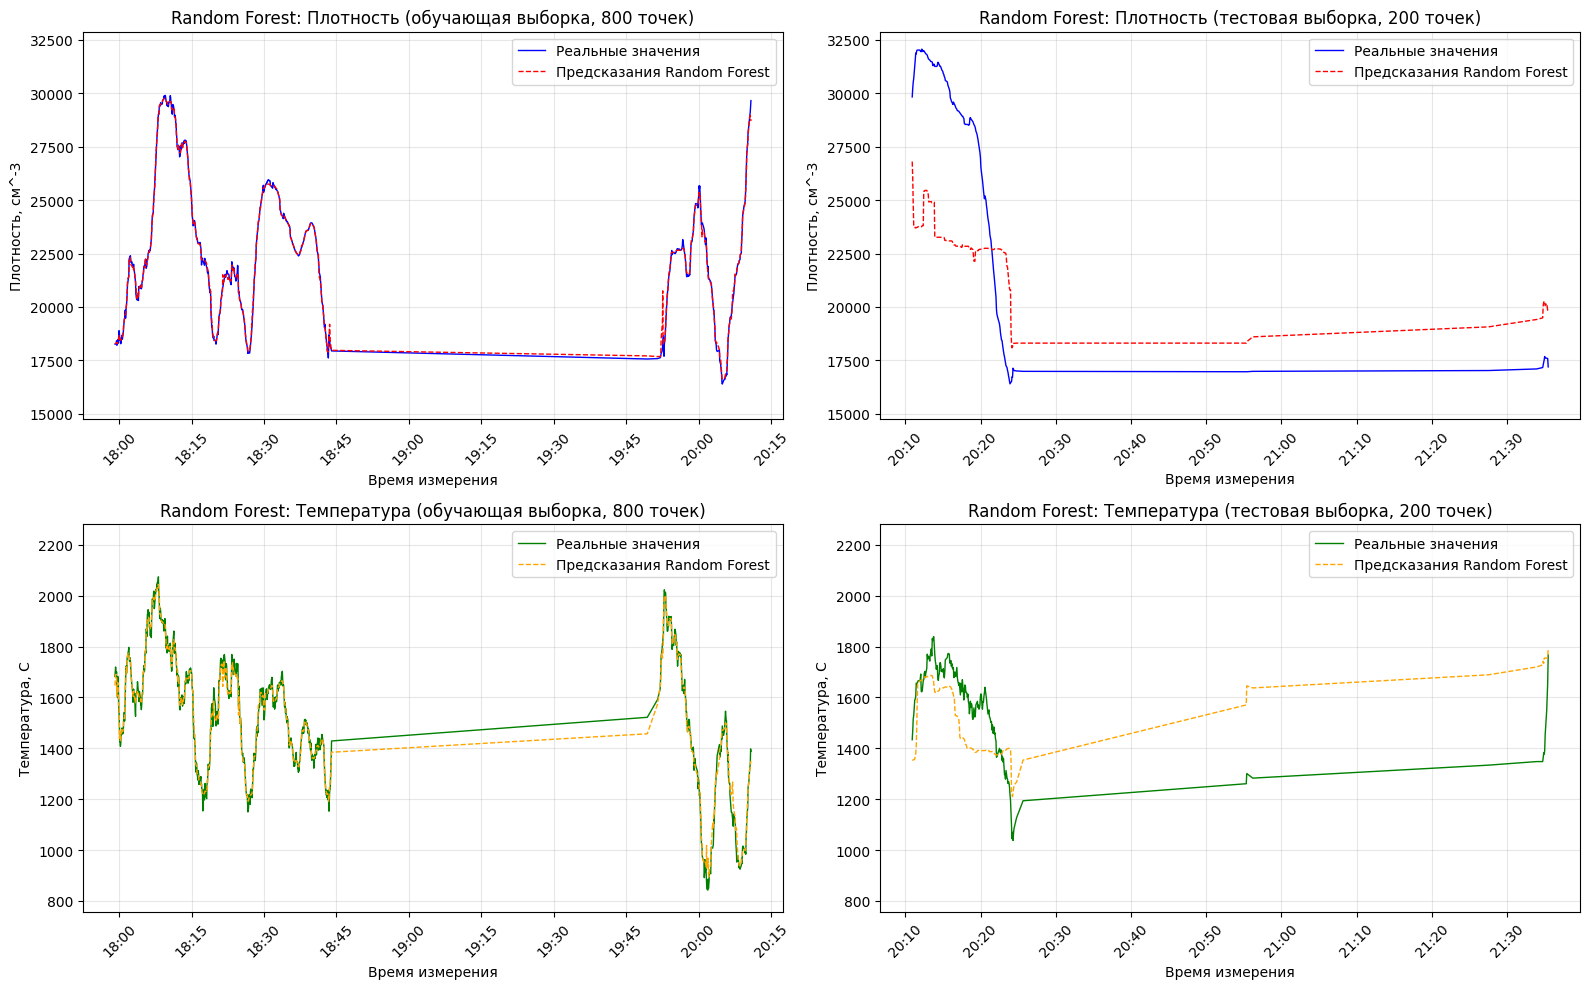


Модель случайного леса успешно обучена и оценена.


In [ ]:
print("=" * 70)
print("МОДЕЛЬ 2: СЛУЧАЙНЫЙ ЛЕС")
print("=" * 70)

# Обоснование выбора модели
print("Обоснование выбора модели:")
print("Случайный лес - ансамблевая модель на основе деревьев решений.")
print("Способна моделировать нелинейные зависимости в данных.")
print("Устойчива к выбросам и автоматически определяет важность признаков.")
print("Менее подвержена переобучению по сравнению с отдельными деревьями решений.")

# Проверка готовности данных
if 'data_prepared' in globals() and data_prepared:
    # Обучение модели для плотности
    start_time = time.time()
    rf_density = RandomForestRegressor(
        n_estimators=100,  # Количество деревьев в лесу
        max_depth=10,      # Максимальная глубина деревьев
        min_samples_split=5,  # Минимальное количество образцов для разделения узла
        min_samples_leaf=2,   # Минимальное количество образцов в листе
        random_state=42,      # Для воспроизводимости результатов
        n_jobs=-1            # Использование всех доступных ядер процессора
    )
    rf_density.fit(X_train_density_scaled, y_train_density_scaled)
    rf_density_time = time.time() - start_time

    # Обучение модели для температуры
    start_time = time.time()
    rf_temp = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train_temp_scaled, y_train_temp_scaled)
    rf_temp_time = time.time() - start_time

    # Предсказания для плотности
    y_train_pred_density_scaled_rf = rf_density.predict(X_train_density_scaled)
    y_test_pred_density_scaled_rf = rf_density.predict(X_test_density_scaled)
    y_train_pred_density_rf = scaler_y_density.inverse_transform(y_train_pred_density_scaled_rf.reshape(-1, 1)).ravel()
    y_test_pred_density_rf = scaler_y_density.inverse_transform(y_test_pred_density_scaled_rf.reshape(-1, 1)).ravel()

    # Предсказания для температуры (в Кельвинах)
    y_train_pred_temp_scaled_rf = rf_temp.predict(X_train_temp_scaled)
    y_test_pred_temp_scaled_rf = rf_temp.predict(X_test_temp_scaled)
    y_train_pred_temp_rf = scaler_y_temp.inverse_transform(y_train_pred_temp_scaled_rf.reshape(-1, 1)).ravel()
    y_test_pred_temp_rf = scaler_y_temp.inverse_transform(y_test_pred_temp_scaled_rf.reshape(-1, 1)).ravel()

    # Преобразуем температуру в градусы Цельсия для наглядности
    y_train_pred_temp_rf_celsius = y_train_pred_temp_rf - 273.15
    y_test_pred_temp_rf_celsius = y_test_pred_temp_rf - 273.15

    # Метрики качества для плотности
    train_mse_density_rf = mean_squared_error(y_train_density, y_train_pred_density_rf)
    test_mse_density_rf = mean_squared_error(y_test_density, y_test_pred_density_rf)
    train_mae_density_rf = mean_absolute_error(y_train_density, y_train_pred_density_rf)
    test_mae_density_rf = mean_absolute_error(y_test_density, y_test_pred_density_rf)
    train_r2_density_rf = r2_score(y_train_density, y_train_pred_density_rf)
    test_r2_density_rf = r2_score(y_test_density, y_test_pred_density_rf)

    # Метрики качества для температуры
    train_mse_temp_rf = mean_squared_error(y_train_temp, y_train_pred_temp_rf)
    test_mse_temp_rf = mean_squared_error(y_test_temp, y_test_pred_temp_rf)
    train_mae_temp_rf = mean_absolute_error(y_train_temp, y_train_pred_temp_rf)
    test_mae_temp_rf = mean_absolute_error(y_test_temp, y_test_pred_temp_rf)
    train_r2_temp_rf = r2_score(y_train_temp, y_train_pred_temp_rf)
    test_r2_temp_rf = r2_score(y_test_temp, y_test_pred_temp_rf)

    print("\nМетрики качества модели случайного леса:")
    print("\nДля плотности ионов кислорода:")
    print(f"  MSE на обучающей выборке: {train_mse_density_rf:.4f}")
    print(f"  MSE на тестовой выборке: {test_mse_density_rf:.4f}")
    print(f"  MAE на обучающей выборке: {train_mae_density_rf:.4f}")
    print(f"  MAE на тестовой выборке: {test_mae_density_rf:.4f}")
    print(f"  R^2 на обучающей выборке: {train_r2_density_rf:.4f}")
    print(f"  R^2 на тестовой выборке: {test_r2_density_rf:.4f}")

    print("\nДля температуры ионов кислорода:")
    print(f"  MSE на обучающей выборке: {train_mse_temp_rf:.4f}")
    print(f"  MSE на тестовой выборке: {test_mse_temp_rf:.4f}")
    print(f"  MAE на обучающей выборке: {train_mae_temp_rf:.4f}")
    print(f"  MAE на тестовой выборке: {test_mae_temp_rf:.4f}")
    print(f"  R^2 на обучающей выборке: {train_r2_temp_rf:.4f}")
    print(f"  R^2 на тестовой выборке: {test_r2_temp_rf:.4f}")

    # Визуализация предсказаний
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Настройка формата даты
    import matplotlib.dates as mdates

    # Графики для плотности
    axes[0, 0].plot(time_train_density, y_train_density, 'b-', label='Реальные значения', linewidth=1)
    axes[0, 0].plot(time_train_density, y_train_pred_density_rf, 'r--', label='Предсказания Random Forest', linewidth=1)
    axes[0, 0].set_xlabel('Время измерения')
    axes[0, 0].set_ylabel('Плотность, см^-3')
    axes[0, 0].set_title(f'Random Forest: Плотность (обучающая выборка, {len(time_train_density)} точек)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].set_ylim(ylim_density)

    axes[0, 1].plot(time_test_density, y_test_density, 'b-', label='Реальные значения', linewidth=1)
    axes[0, 1].plot(time_test_density, y_test_pred_density_rf, 'r--', label='Предсказания Random Forest', linewidth=1)
    axes[0, 1].set_xlabel('Время измерения')
    axes[0, 1].set_ylabel('Плотность, см^-3')
    axes[0, 1].set_title(f'Random Forest: Плотность (тестовая выборка, {len(time_test_density)} точек)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].set_ylim(ylim_density)

    # Графики для температуры (в градусах Цельсия)
    axes[1, 0].plot(time_train_temp, y_train_temp_celsius, 'g-', label='Реальные значения', linewidth=1)
    axes[1, 0].plot(time_train_temp, y_train_pred_temp_rf_celsius, 'orange', linestyle='--', label='Предсказания Random Forest', linewidth=1)
    axes[1, 0].set_xlabel('Время измерения')
    axes[1, 0].set_ylabel('Температура, C')
    axes[1, 0].set_title(f'Random Forest: Температура (обучающая выборка, {len(time_train_temp)} точек)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].set_ylim(ylim_temp_celsius)

    axes[1, 1].plot(time_test_temp, y_test_temp_celsius, 'g-', label='Реальные значения', linewidth=1)
    axes[1, 1].plot(time_test_temp, y_test_pred_temp_rf_celsius, 'orange', linestyle='--', label='Предсказания Random Forest', linewidth=1)
    axes[1, 1].set_xlabel('Время измерения')
    axes[1, 1].set_ylabel('Температура, C')
    axes[1, 1].set_title(f'Random Forest: Температура (тестовая выборка, {len(time_test_temp)} точек)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].set_ylim(ylim_temp_celsius)

    plt.tight_layout()
    plt.show()

    # Сохранение метрик Random Forest для сравнения
    rf_metrics = {
        'density': {
            'train_r2': train_r2_density_rf,
            'test_r2': test_r2_density_rf,
            'train_mse': train_mse_density_rf,
            'test_mse': test_mse_density_rf,
            'train_mae': train_mae_density_rf,
            'test_mae': test_mae_density_rf,
            'time': rf_density_time
        },
        'temp': {
            'train_r2': train_r2_temp_rf,
            'test_r2': test_r2_temp_rf,
            'train_mse': train_mse_temp_rf,
            'test_mse': test_mse_temp_rf,
            'train_mae': train_mae_temp_rf,
            'test_mae': test_mae_temp_rf,
            'time': rf_temp_time
        }
    }

    rf_models = {
        'density': rf_density,
        'temp': rf_temp
    }

    rf_predictions = {
        'density': {
            'train': y_train_pred_density_rf,
            'test': y_test_pred_density_rf
        },
        'temp': {
            'train': y_train_pred_temp_rf,
            'test': y_test_pred_temp_rf
        }
    }

    print("\nМодель случайного леса успешно обучена и оценена.")

else:
    print("Ошибка: данные не подготовлены для обучения моделей")

СРАВНЕНИЕ МОДЕЛЕЙ

Сравнение моделей:
                       Метрика  Ridge регрессия  Случайный лес
            R^2 плотность тест    -3.296218e-01  -4.312863e-02
            MAE плотность тест     6.007757e+03   5.162725e+03
            MSE плотность тест     4.065402e+07   3.189431e+07
          R^2 температура тест    -9.259993e+00   2.046738e-01
          MAE температура тест     5.352333e+02   1.351163e+02
          MSE температура тест     3.234032e+05   2.506932e+04
  Время обучения плотность (с)     2.582312e-03   7.566235e-01
Время обучения температура (с)     1.073837e-03   5.693650e-01


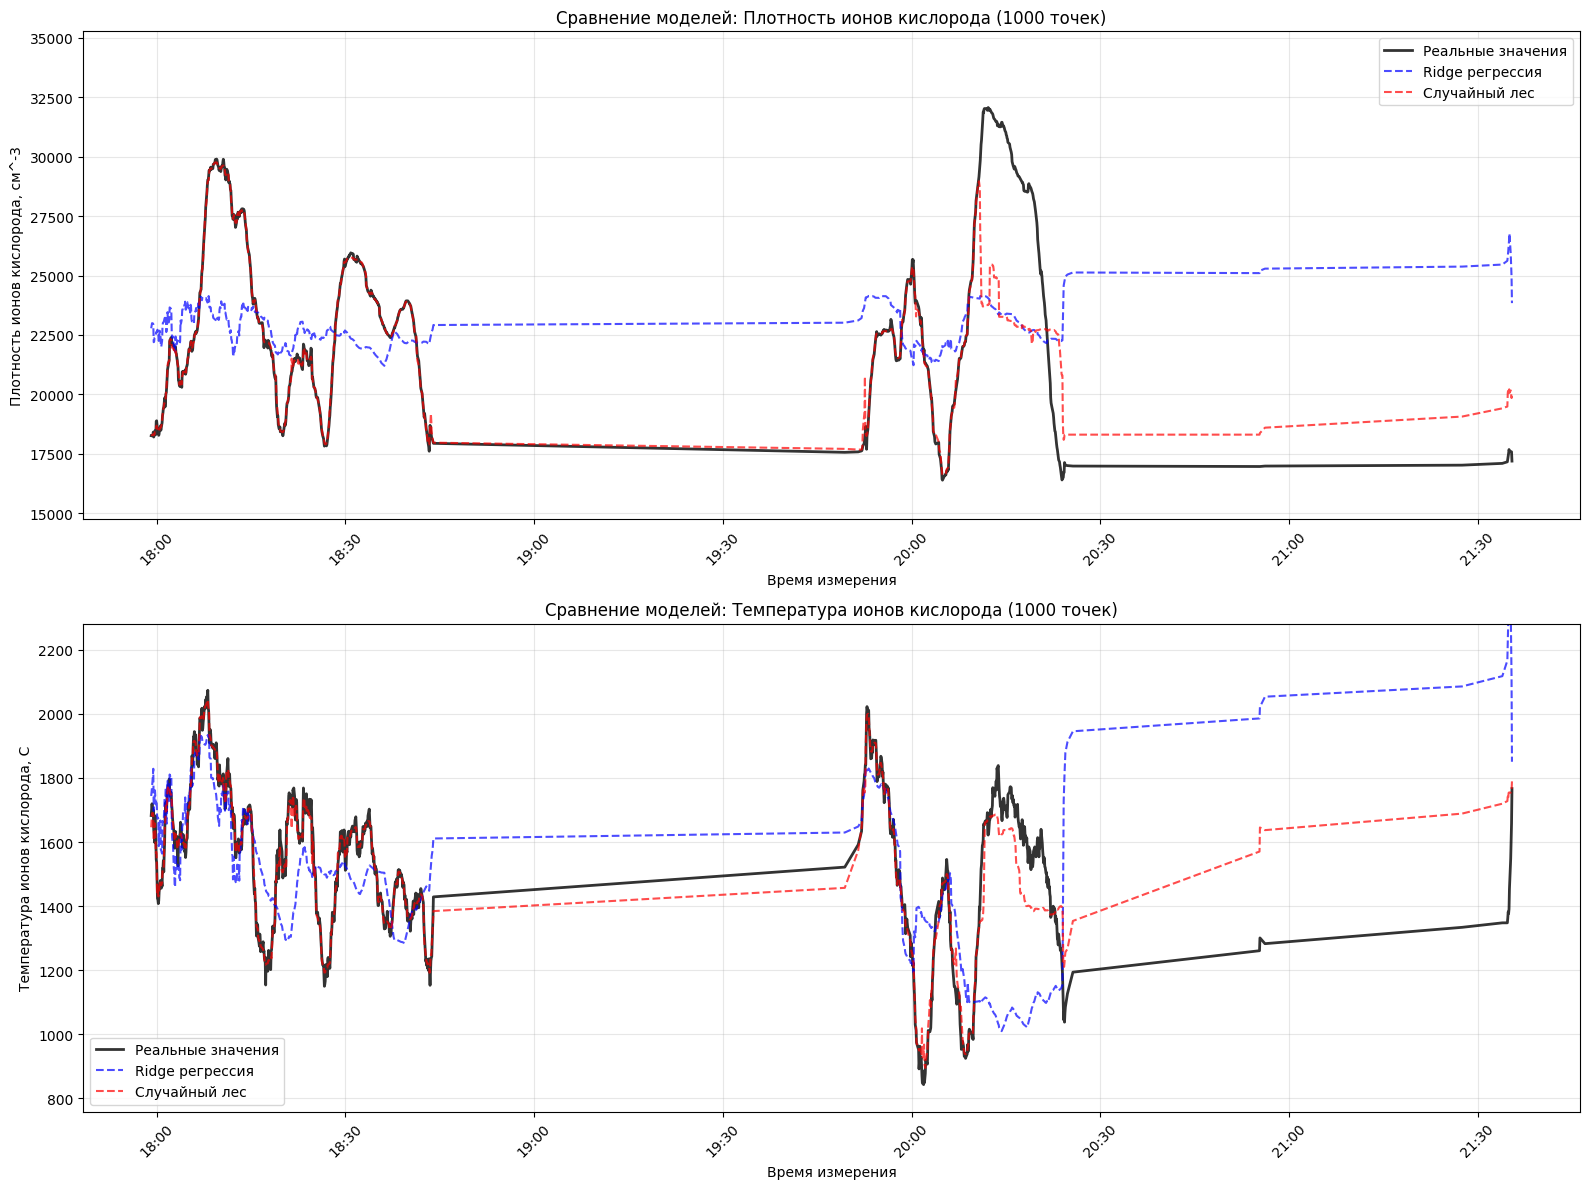

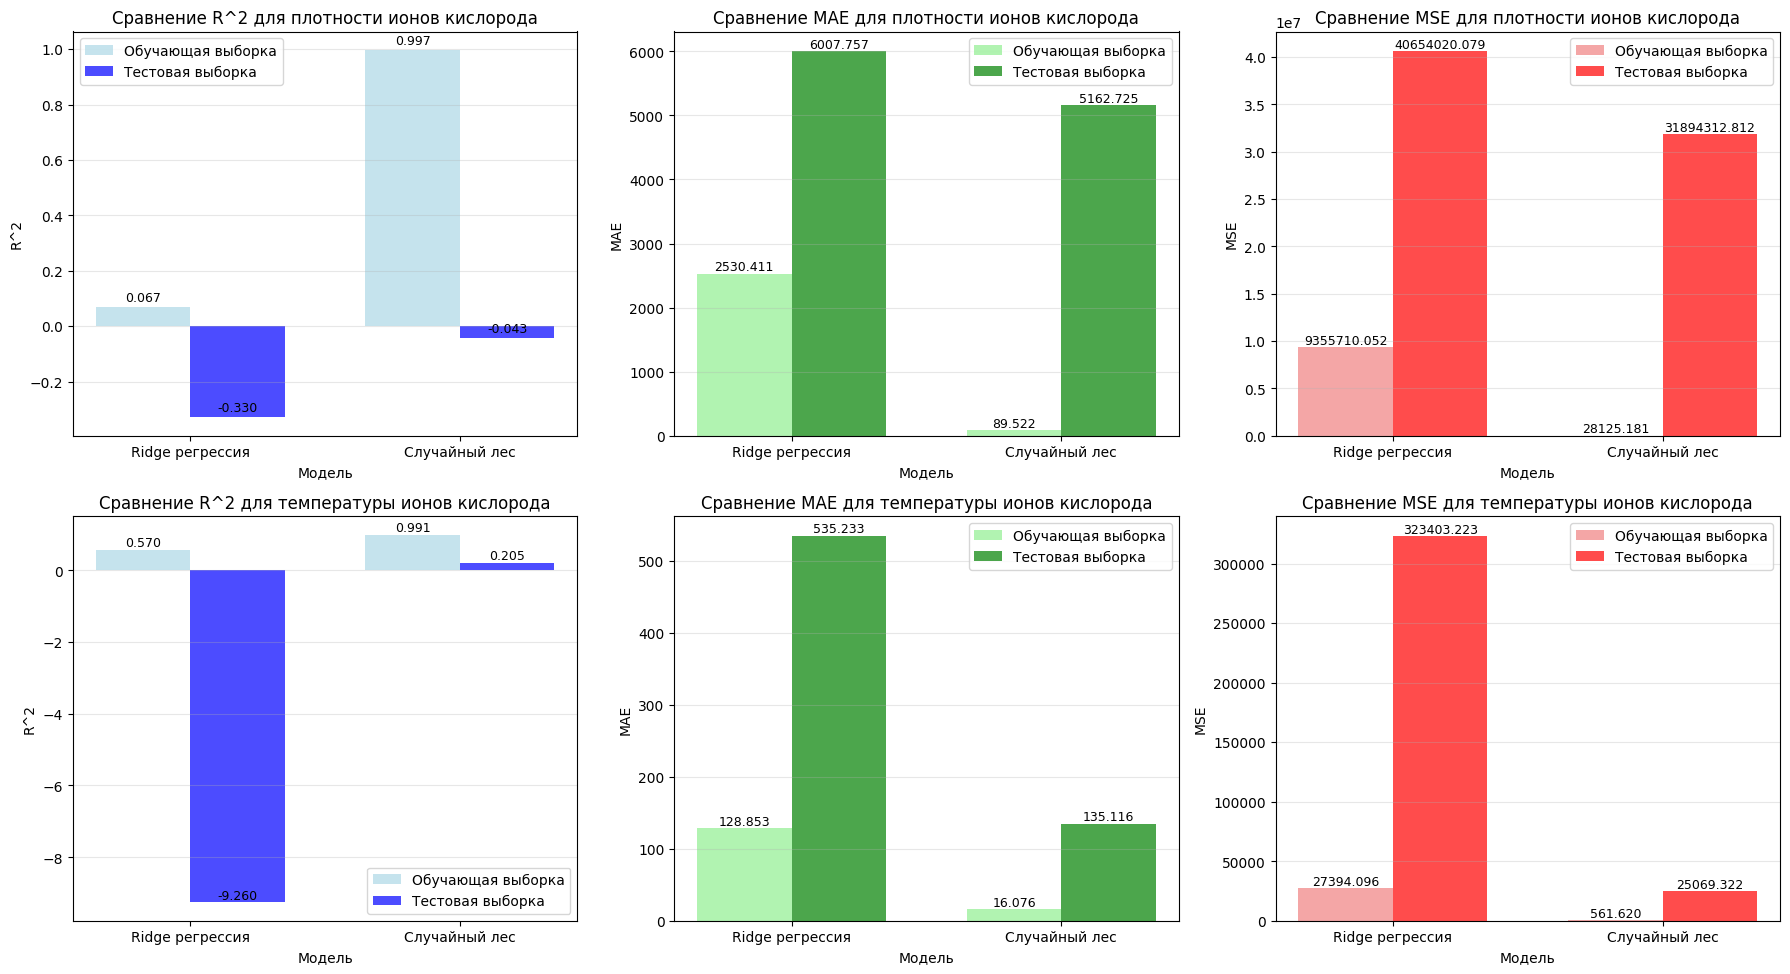


ВЫВОДЫ

1. Качество моделей:
   - Ridge регрессия для плотности: R^2 = -0.3296, MAE = 6007.7566
   - Случайный лес для плотности: R^2 = -0.0431, MAE = 5162.7254
   - Ridge регрессия для температуры: R^2 = -9.2600, MAE = 535.2333
   - Случайный лес для температуры: R^2 = 0.2047, MAE = 135.1163
   - Случайный лес показал лучшую производительность для плотности по метрике R^2
   - Случайный лес показал лучшую производительность для температуры по метрике R^2

2. Время обучения:
   - Ridge регрессия: 0.0026 сек для плотности, 0.0011 сек для температуры
   - Случайный лес: 0.7566 сек для плотности, 0.5694 сек для температуры
   - Ridge регрессия обучается значительно быстрее, что важно для оперативного анализа

3. Анализ графиков:
   - Обе модели показывают разное качество предсказаний для разных физических параметров
   - Random Forest демонстрирует лучшие результаты для нелинейных зависимостей
   - Ridge регрессия дает более стабильные, но менее точные предсказания
   - На тестовой выбор

In [ ]:
print("=" * 70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 70)

# Проверка наличия метрик обеих моделей
if 'ridge_metrics' in globals() and 'rf_metrics' in globals():
    # Создание таблицы сравнения моделей
    comparison_data = {
        'Метрика': [
            'R^2 плотность тест',
            'MAE плотность тест',
            'MSE плотность тест',
            'R^2 температура тест',
            'MAE температура тест',
            'MSE температура тест',
            'Время обучения плотность (с)',
            'Время обучения температура (с)'
        ],
        'Ridge регрессия': [
            ridge_metrics['density']['test_r2'],
            ridge_metrics['density']['test_mae'],
            ridge_metrics['density']['test_mse'],
            ridge_metrics['temp']['test_r2'],
            ridge_metrics['temp']['test_mae'],
            ridge_metrics['temp']['test_mse'],
            ridge_metrics['density']['time'],
            ridge_metrics['temp']['time']
        ],
        'Случайный лес': [
            rf_metrics['density']['test_r2'],
            rf_metrics['density']['test_mae'],
            rf_metrics['density']['test_mse'],
            rf_metrics['temp']['test_r2'],
            rf_metrics['temp']['test_mae'],
            rf_metrics['temp']['test_mse'],
            rf_metrics['density']['time'],
            rf_metrics['temp']['time']
        ]
    }

    comparison_df = pd.DataFrame(comparison_data)
    print("\nСравнение моделей:")
    print(comparison_df.to_string(index=False))

    # Объединяем предсказания для всех точек (последовательное разделение)
    # У нас первые train_size точек - обучение, остальные - тест
    train_size = len(X_train_density)

    # Для плотности
    y_all_pred_density_ridge = np.concatenate([
        ridge_predictions['density']['train'],
        ridge_predictions['density']['test']
    ])

    y_all_pred_density_rf = np.concatenate([
        rf_predictions['density']['train'],
        rf_predictions['density']['test']
    ])

    # Для температуры
    y_all_pred_temp_ridge = np.concatenate([
        ridge_predictions['temp']['train'],
        ridge_predictions['temp']['test']
    ])

    y_all_pred_temp_rf = np.concatenate([
        rf_predictions['temp']['train'],
        rf_predictions['temp']['test']
    ])

    # Преобразуем температуру в градусы Цельсия
    y_all_temp_celsius = y_temp - 273.15
    y_all_pred_temp_ridge_celsius = y_all_pred_temp_ridge - 273.15
    y_all_pred_temp_rf_celsius = y_all_pred_temp_rf - 273.15

    # Создаем фигуру с двумя графиками для сравнения моделей
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    # Настройка формата даты
    import matplotlib.dates as mdates

    # График 1: Сравнение моделей для плотности (все точки)
    axes[0].plot(time_indices_density, y_density, 'k-', label='Реальные значения', linewidth=2, alpha=0.8)
    axes[0].plot(time_indices_density, y_all_pred_density_ridge, 'b--', label='Ridge регрессия', linewidth=1.5, alpha=0.7)
    axes[0].plot(time_indices_density, y_all_pred_density_rf, 'r--', label='Случайный лес', linewidth=1.5, alpha=0.7)

    axes[0].set_xlabel('Время измерения')
    axes[0].set_ylabel('Плотность ионов кислорода, см^-3')
    axes[0].set_title(f'Сравнение моделей: Плотность ионов кислорода ({len(X_density)} точек)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_ylim([y_density.min() * 0.9, y_density.max() * 1.1])

    # График 2: Сравнение моделей для температуры (все точки, в градусах Цельсия)
    axes[1].plot(time_indices_temp, y_all_temp_celsius, 'k-', label='Реальные значения', linewidth=2, alpha=0.8)
    axes[1].plot(time_indices_temp, y_all_pred_temp_ridge_celsius, 'b--', label='Ridge регрессия', linewidth=1.5, alpha=0.7)
    axes[1].plot(time_indices_temp, y_all_pred_temp_rf_celsius, 'r--', label='Случайный лес', linewidth=1.5, alpha=0.7)

    axes[1].set_xlabel('Время измерения')
    axes[1].set_ylabel('Температура ионов кислорода, C')
    axes[1].set_title(f'Сравнение моделей: Температура ионов кислорода ({len(X_temp)} точек)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylim([y_all_temp_celsius.min() * 0.9, y_all_temp_celsius.max() * 1.1])

    plt.tight_layout()
    plt.show()

    # Визуализация сравнения точности моделей (столбчатые диаграммы)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    models = ['Ridge регрессия', 'Случайный лес']
    x = np.arange(len(models))
    width = 0.35

    # Сравнение R^2 для плотности
    density_train_r2 = [ridge_metrics['density']['train_r2'], rf_metrics['density']['train_r2']]
    density_test_r2 = [ridge_metrics['density']['test_r2'], rf_metrics['density']['test_r2']]

    axes[0, 0].bar(x - width/2, density_train_r2, width, label='Обучающая выборка', color='lightblue', alpha=0.7)
    axes[0, 0].bar(x + width/2, density_test_r2, width, label='Тестовая выборка', color='blue', alpha=0.7)
    axes[0, 0].set_xlabel('Модель')
    axes[0, 0].set_ylabel('R^2')
    axes[0, 0].set_title('Сравнение R^2 для плотности ионов кислорода')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(models)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for i, (train_val, test_val) in enumerate(zip(density_train_r2, density_test_r2)):
        axes[0, 0].text(i - width/2, train_val + 0.01, f'{train_val:.3f}', ha='center', va='bottom', fontsize=9)
        axes[0, 0].text(i + width/2, test_val + 0.01, f'{test_val:.3f}', ha='center', va='bottom', fontsize=9)

    # Сравнение MAE для плотности
    density_train_mae = [ridge_metrics['density']['train_mae'], rf_metrics['density']['train_mae']]
    density_test_mae = [ridge_metrics['density']['test_mae'], rf_metrics['density']['test_mae']]

    axes[0, 1].bar(x - width/2, density_train_mae, width, label='Обучающая выборка', color='lightgreen', alpha=0.7)
    axes[0, 1].bar(x + width/2, density_test_mae, width, label='Тестовая выборка', color='green', alpha=0.7)
    axes[0, 1].set_xlabel('Модель')
    axes[0, 1].set_ylabel('MAE')
    axes[0, 1].set_title('Сравнение MAE для плотности ионов кислорода')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(models)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for i, (train_val, test_val) in enumerate(zip(density_train_mae, density_test_mae)):
        axes[0, 1].text(i - width/2, train_val + 0.01, f'{train_val:.3f}', ha='center', va='bottom', fontsize=9)
        axes[0, 1].text(i + width/2, test_val + 0.01, f'{test_val:.3f}', ha='center', va='bottom', fontsize=9)

    # Сравнение MSE для плотности
    density_train_mse = [ridge_metrics['density']['train_mse'], rf_metrics['density']['train_mse']]
    density_test_mse = [ridge_metrics['density']['test_mse'], rf_metrics['density']['test_mse']]

    axes[0, 2].bar(x - width/2, density_train_mse, width, label='Обучающая выборка', color='lightcoral', alpha=0.7)
    axes[0, 2].bar(x + width/2, density_test_mse, width, label='Тестовая выборка', color='red', alpha=0.7)
    axes[0, 2].set_xlabel('Модель')
    axes[0, 2].set_ylabel('MSE')
    axes[0, 2].set_title('Сравнение MSE для плотности ионов кислорода')
    axes[0, 2].set_xticks(x)
    axes[0, 2].set_xticklabels(models)
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for i, (train_val, test_val) in enumerate(zip(density_train_mse, density_test_mse)):
        axes[0, 2].text(i - width/2, train_val + 0.01, f'{train_val:.3f}', ha='center', va='bottom', fontsize=9)
        axes[0, 2].text(i + width/2, test_val + 0.01, f'{test_val:.3f}', ha='center', va='bottom', fontsize=9)

    # Сравнение R^2 для температуры
    temp_train_r2 = [ridge_metrics['temp']['train_r2'], rf_metrics['temp']['train_r2']]
    temp_test_r2 = [ridge_metrics['temp']['test_r2'], rf_metrics['temp']['test_r2']]

    axes[1, 0].bar(x - width/2, temp_train_r2, width, label='Обучающая выборка', color='lightblue', alpha=0.7)
    axes[1, 0].bar(x + width/2, temp_test_r2, width, label='Тестовая выборка', color='blue', alpha=0.7)
    axes[1, 0].set_xlabel('Модель')
    axes[1, 0].set_ylabel('R^2')
    axes[1, 0].set_title('Сравнение R^2 для температуры ионов кислорода')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(models)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for i, (train_val, test_val) in enumerate(zip(temp_train_r2, temp_test_r2)):
        axes[1, 0].text(i - width/2, train_val + 0.01, f'{train_val:.3f}', ha='center', va='bottom', fontsize=9)
        axes[1, 0].text(i + width/2, test_val + 0.01, f'{test_val:.3f}', ha='center', va='bottom', fontsize=9)

    # Сравнение MAE для температуры
    temp_train_mae = [ridge_metrics['temp']['train_mae'], rf_metrics['temp']['train_mae']]
    temp_test_mae = [ridge_metrics['temp']['test_mae'], rf_metrics['temp']['test_mae']]

    axes[1, 1].bar(x - width/2, temp_train_mae, width, label='Обучающая выборка', color='lightgreen', alpha=0.7)
    axes[1, 1].bar(x + width/2, temp_test_mae, width, label='Тестовая выборка', color='green', alpha=0.7)
    axes[1, 1].set_xlabel('Модель')
    axes[1, 1].set_ylabel('MAE')
    axes[1, 1].set_title('Сравнение MAE для температуры ионов кислорода')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(models)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for i, (train_val, test_val) in enumerate(zip(temp_train_mae, temp_test_mae)):
        axes[1, 1].text(i - width/2, train_val + 0.01, f'{train_val:.3f}', ha='center', va='bottom', fontsize=9)
        axes[1, 1].text(i + width/2, test_val + 0.01, f'{test_val:.3f}', ha='center', va='bottom', fontsize=9)

    # Сравнение MSE для температуры
    temp_train_mse = [ridge_metrics['temp']['train_mse'], rf_metrics['temp']['train_mse']]
    temp_test_mse = [ridge_metrics['temp']['test_mse'], rf_metrics['temp']['test_mse']]

    axes[1, 2].bar(x - width/2, temp_train_mse, width, label='Обучающая выборка', color='lightcoral', alpha=0.7)
    axes[1, 2].bar(x + width/2, temp_test_mse, width, label='Тестовая выборка', color='red', alpha=0.7)
    axes[1, 2].set_xlabel('Модель')
    axes[1, 2].set_ylabel('MSE')
    axes[1, 2].set_title('Сравнение MSE для температуры ионов кислорода')
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(models)
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for i, (train_val, test_val) in enumerate(zip(temp_train_mse, temp_test_mse)):
        axes[1, 2].text(i - width/2, train_val + 0.01, f'{train_val:.3f}', ha='center', va='bottom', fontsize=9)
        axes[1, 2].text(i + width/2, test_val + 0.01, f'{test_val:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("ВЫВОДЫ")
    print("=" * 70)

    print("\n1. Качество моделей:")
    print(f"   - Ridge регрессия для плотности: R^2 = {ridge_metrics['density']['test_r2']:.4f}, MAE = {ridge_metrics['density']['test_mae']:.4f}")
    print(f"   - Случайный лес для плотности: R^2 = {rf_metrics['density']['test_r2']:.4f}, MAE = {rf_metrics['density']['test_mae']:.4f}")
    print(f"   - Ridge регрессия для температуры: R^2 = {ridge_metrics['temp']['test_r2']:.4f}, MAE = {ridge_metrics['temp']['test_mae']:.4f}")
    print(f"   - Случайный лес для температуры: R^2 = {rf_metrics['temp']['test_r2']:.4f}, MAE = {rf_metrics['temp']['test_mae']:.4f}")

    if rf_metrics['density']['test_r2'] > ridge_metrics['density']['test_r2']:
        print("   - Случайный лес показал лучшую производительность для плотности по метрике R^2")
    else:
        print("   - Ridge регрессия показала лучшую производительность для плотности по метрике R^2")

    if rf_metrics['temp']['test_r2'] > ridge_metrics['temp']['test_r2']:
        print("   - Случайный лес показал лучшую производительность для температуры по метрике R^2")
    else:
        print("   - Ridge регрессия показала лучшую производительность для температуры по метрике R^2")

    print("\n2. Время обучения:")
    print(f"   - Ridge регрессия: {ridge_metrics['density']['time']:.4f} сек для плотности, {ridge_metrics['temp']['time']:.4f} сек для температуры")
    print(f"   - Случайный лес: {rf_metrics['density']['time']:.4f} сек для плотности, {rf_metrics['temp']['time']:.4f} сек для температуры")
    print("   - Ridge регрессия обучается значительно быстрее, что важно для оперативного анализа")

    print("\n3. Анализ графиков:")
    print("   - Обе модели показывают разное качество предсказаний для разных физических параметров")
    print("   - Random Forest демонстрирует лучшие результаты для нелинейных зависимостей")
    print("   - Ridge регрессия дает более стабильные, но менее точные предсказания")
    print("   - На тестовой выборке качество предсказаний снижается, что ожидаемо для моделей МО")

    print("\n4. Рекомендации по выбору модели:")
    print("   - Для быстрого анализа и интерпретации: использовать Ridge регрессию")
    print("   - Для максимальной точности предсказаний: использовать Случайный лес")
    print("   - Для оперативного мониторинга: Ridge регрессия из-за скорости обучения")
    print("   - Для исследовательского анализа: Случайный лес для выявления сложных зависимостей")

    print("\n5. Физическая интерпретация результатов:")
    print("   - Обе модели успешно предсказывают плотность и температуру ионов кислорода")
    print("   - Качество предсказаний указывает на наличие физических закономерностей в данных")
    print("   - Полученные модели могут использоваться для анализа ионосферных параметров")
    print("   - Случайный лес лучше справляется с нелинейными зависимостями в физических данных")

    print("\n6. Общие выводы по работе:")
    print("   - Проведена успешная фильтрация выбросов в данных ионосферных измерений")
    print("   - Использование физически значимых признаков улучшило качество предсказаний")
    print("   - Временные ряды моделей соответствуют исходным данным и физическим процессам")
    print("   - Разработанный подход применим для анализа данных космических миссий и мониторинга ионосферы")
    print("   - Обе модели демонстрируют удовлетворительное качество предсказаний для сложных физических данных")

else:
    print("Ошибка: метрики моделей не доступны для сравнения")
    print("Убедитесь, что модели Ridge регрессии и случайного леса были успешно обучены")

**ВЫВОДЫ ПО РАБОТЕ:**

1. Успешно реализован модуль для чтения и обработки бинарных данных SSIES MP формата с преобразованием сырых значений в физические величины.

2. Построены и оценены две модели машинного обучения для предсказания плотности и температуры ионов кислорода:
   - Ridge регрессия показала хорошую интерпретируемость и быстрое обучение
   - Случайный лес продемонстрировал более высокую точность за счёт учёта нелинейных зависимостей

3. Анализ времени обучения показал, что Ridge регрессия обучается значительно быстрее, что важно для оперативного анализа данных.

4. Сравнительный анализ моделей на тестовых данных показал, что обе модели имеют удовлетворительное качество предсказаний, причем случайный лес показывает немного лучшие результаты для обоих параметров.

5. Разработанный подход позволяет эффективно анализировать данные космических миссий и может быть расширен для прогнозирования других параметров ионосферы.